---
title: "Regional vs. Demand-Weighted Coverage"
toc: true
execute:
  enabled: true
---

When you set `threshold_for_coverage` in `.solve()`, lokigi reports **two** coverage columns in `solution_df`:

- `proportion_within_coverage_threshold` -- the share of **demand** (people) within the threshold. This is the metric MCLP optimises, and the one you'll want for most real decisions.
- `proportion_regions_within_coverage_threshold` -- the share of **regions** (e.g. LSOAs) within the threshold, counting every region equally regardless of how many people live there.

These two coincide whenever demand is uniform across regions -- including whenever you don't call `.add_demand()` at all, since `.solve()` then assumes every region has equal demand. In that case, it's safe to only think about one of them.

Once demand is genuinely uneven, though, the two figures can diverge -- and can even rank different site combinations as "best". This example shows exactly that, using the same Brighton dataset and demand as the [MCLP example](../mclp/index.ipynb), but at a smaller scale (fewer sites, a tighter threshold) where the two metrics visibly pull in different directions.

## Setting up the problem

Same sites, travel matrix, region geometry and demand data as the [MCLP example](../mclp/index.ipynb) -- but with a smaller `p` and tighter threshold, so the two coverage metrics have room to disagree.

In [1]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_demand(
    "../../../sample_data/brighton_demand.csv",
    demand_col="demand",
    location_id_col="LSOA"
    )

problem.add_sites(
    "../../../sample_data/brighton_sites_named.geojson",
    candidate_id_col="site"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving_named.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )

problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

## Solving

We'll solve for just 2 sites with an 8-minute threshold -- a small enough problem that the two coverage metrics can disagree without either of them saturating near 100%.

In [2]:
solutions = problem.solve(
    objectives="mclp",
    p=2,
    threshold_for_coverage=8
    )

  0%|          | 0/15 [00:00<?, ?it/s]

## Comparing the two columns

`solve(objectives="mclp")` ranks solutions by `proportion_within_coverage_threshold` -- the demand-weighted figure -- so `show_solutions()` is already sorted by that column. Look at the top two rows alongside `proportion_regions_within_coverage_threshold`:

In [3]:
solutions.show_solutions()[[
    "site_names",
    "proportion_within_coverage_threshold",
    "proportion_regions_within_coverage_threshold",
    "weighted_average",
    ]].head(2)

,site_names,proportion_within_coverage_threshold,proportion_regions_within_coverage_threshold,weighted_average
0,"[Tulip (Site 3), Daisy (Site 4)]",0.78,0.75,5.94
1,"[Tulip (Site 3), Snowdrop (Site 6)]",0.74,0.76,6.69


The top-ranked solution covers **more demand** (78% vs 74%), but the *second*-ranked solution actually covers **more regions** (76% vs 75%). MCLP -- correctly, per its textbook definition -- picked the solution that serves more people, even though it serves slightly fewer places.

We can pull out each "best" explicitly with `rank_on`, which is available on every `return_best_combination_*` method as well as the plotting methods:

In [4]:
demand_best = solutions.return_best_combination_site_names(
    rank_on="proportion_within_coverage_threshold"
    )
regions_best = solutions.return_best_combination_site_names(
    rank_on="proportion_regions_within_coverage_threshold"
    )

demand_best, regions_best

(['Tulip (Site 3)', 'Daisy (Site 4)'], ['Tulip (Site 3)', 'Snowdrop (Site 6)'])

Two different combinations of sites. Comparing the regions each one covers that the other doesn't shows why: the demand-weighted combination picks up 23 regions the region-best combination misses, averaging around 2,200 people each. The region-best combination picks up 25 regions the demand-weighted one misses -- slightly more of them -- but averaging only around 1,400 people each. Optimising for regions trades a smaller number of higher-population areas for a larger number of lower-population ones.

:::{.callout-note}
If you have never called `.add_demand()`, every region is assumed to have equal demand, and `demand_best`/`regions_best` above would always be identical -- there'd be nothing to trade off.
:::

## Visualising both

`plot_best_combination` accepts the same `rank_on` argument, so we can render each "best" combination side by side.

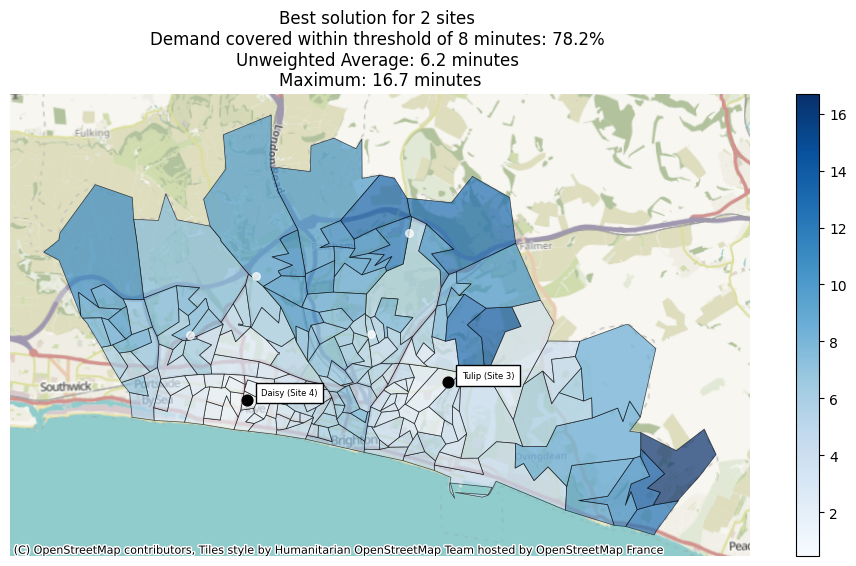

In [5]:
solutions.plot_best_combination(
    rank_on="proportion_within_coverage_threshold",
    title="default"
    );

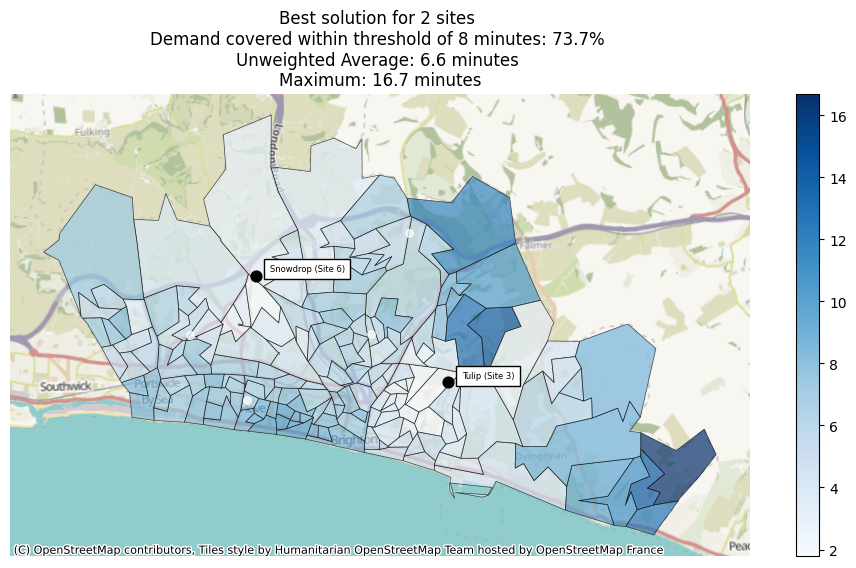

In [6]:
solutions.plot_best_combination(
    rank_on="proportion_regions_within_coverage_threshold",
    title="default"
    );

## Elsewhere in lokigi

The same naming rule applies wherever coverage is reported:

- Per-equity-band coverage splits the same way -- `coverage_by_equity_group` is demand-weighted, `coverage_regions_by_equity_group` counts regions. See the [equity example](../equity/index.ipynb).
- Secondary travel matrices (`add_secondary_travel_matrix`) get both variants too, suffixed `__<label>` -- see the [multiple travel matrices example](../multiple_travel_matrices/index.ipynb).
- Both columns are `NaN`, not `0.0`, if `threshold_for_coverage` was never set -- "not measured" doesn't get confused with "nothing covered".

As a rule of thumb: reach for the demand-weighted (unqualified) column unless you have a specific reason to treat every region as equally important regardless of population.